# S&P 500 Equity+Options: Portfolio Allocation

This notebook advances the ten best primary-label model configurations from
the equal-weight baseline and tests five point-in-time allocation methods. It
asks whether portfolio sizing improves validation performance without
changing the prediction model or consulting the holdout.

**Learning objectives**

1. Apply the top-ten, one-checkpoint-per-configuration selection funnel.
2. Compare score weighting, inverse volatility, risk parity, MVO, and HRP on
   the same validation predictions.
3. Measure how the number of selected stocks changes allocation performance.
4. Separate a validation improvement from evidence of out-of-sample efficacy.

**Book reference:** Chapter 17, Sections 17.2-17.8.

**Prerequisites:** `14_backtest` and its registry-backed equal-weight
baselines. Signals form after Friday's close and execute at the next available
open, normally Monday. The 2021 holdout remains sealed throughout. The
current-constituent universe retains survivorship bias, so results describe
this retrospective roster rather than historical S&P 500 membership or a
prospective index population.

In [1]:
"""S&P 500 Equity+Options: portfolio allocation sweep."""

import sqlite3
import time
import warnings

import matplotlib.pyplot as plt
import polars as pl

warnings.filterwarnings("ignore")

from case_studies.utils.backtest_loaders import (
    get_backtest_config,
    load_backtest_prices_for,
    warmup_periods_for,
)
from case_studies.utils.backtest_presets import build_backtest_spec
from case_studies.utils.backtest_runner import run_backtest
from case_studies.utils.registry import (
    backtest_hash_from_parts,
    read_predictions,
    resolve_best_predictions,
)
from case_studies.utils.sweep_config import (
    get_allocators,
    get_checkpoints_per_config,
    get_top_k_values_for,
    get_top_n_predictions,
)
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title

In [2]:
CASE_STUDY_ID = "sp500_equity_option_analytics"
LABEL = ""
MAX_SYMBOLS = 0
SKIP_EXPENSIVE_ALLOC = False
TOP_N_PREDICTIONS = None

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
bt_config = get_backtest_config(CASE_STUDY_ID)
if TOP_N_PREDICTIONS is None:
    TOP_N_PREDICTIONS = get_top_n_predictions(CASE_STUDY_ID, "allocation")
CHECKPOINTS_PER_CONFIG = get_checkpoints_per_config(CASE_STUDY_ID)
if not LABEL:
    LABEL = bt_config.primary_label

print(
    f"Case study: {CASE_STUDY_ID}; label: {LABEL}; "
    f"top configs: {TOP_N_PREDICTIONS}; checkpoints/config: {CHECKPOINTS_PER_CONFIG}"
)

Case study: sp500_equity_option_analytics; label: fwd_ret_5d; top configs: 10; checkpoints/config: 1


## 1. Advance the baseline winners

Selection uses validation Sharpe and counts distinct `(family, config_name)`
pairs. Each configuration enters through its best full-coverage checkpoint,
so a long checkpoint grid cannot crowd other model families out of the
allocation round.

In [4]:
top_preds = resolve_best_predictions(
    CASE_STUDY_ID,
    LABEL,
    split="validation",
    stage="signal",
    top_n=TOP_N_PREDICTIONS,
    checkpoints_per_config=CHECKPOINTS_PER_CONFIG,
)
if len(top_preds) != TOP_N_PREDICTIONS:
    raise RuntimeError(
        f"Expected {TOP_N_PREDICTIONS} advancing configurations, found {len(top_preds)}"
    )

selected_hashes = top_preds["prediction_hash"].to_list()
top_preds.select("source", "prediction_hash", "sharpe")

source,prediction_hash,sharpe
str,str,f64
"""deep_learning/nlinear""","""07841c23bf72""",0.825506
"""latent_factors/sdf""","""11292ff56cd3""",0.809035
"""linear/lasso_f0.85""","""ffbc8da2e094""",0.71091
"""linear/enet_f0.85""","""57277c1b6cd3""",0.705762
"""latent_factors/cae""","""0951300b4ea1""",0.692184
"""latent_factors/ipca""","""8d344d7939d3""",0.649769
"""deep_learning/lstm_h64""","""713ae9beb28c""",0.646247
"""linear/lasso_f0.7""","""09a1df688ee4""",0.595097
"""linear/enet_f0.7""","""edf60acff373""",0.584012


The primary-label funnel advances NLinear, SDF, CAE, IPCA, LSTM, PatchTST,
and four regularized linear configurations. These are the inputs to the
allocation comparison, not conclusions from it.

In [5]:
prices = load_backtest_prices_for(
    CASE_STUDY_ID,
    LABEL,
    split="validation",
    warmup_periods=warmup_periods_for(CASE_STUDY_ID),
    max_symbols=MAX_SYMBOLS,
)
n_assets = prices["symbol"].n_unique()
print(f"Price support: {len(prices):,} rows across {n_assets} historical symbols")

Price support: 505,922 rows across 614 historical symbols


## 2. Sweep alternative allocators

Equal weight is the baseline established in `14_backtest`, so it is not an
allocation-stage method. The sweep combines three concentration levels with
five alternatives. Existing hashes are reused; only missing combinations run.

In [6]:
TOP_K_VALUES = get_top_k_values_for(CASE_STUDY_ID, LABEL, n_assets)
ALLOC_CONFIGS = get_allocators(CASE_STUDY_ID)
if SKIP_EXPENSIVE_ALLOC:
    ALLOC_CONFIGS = [
        alloc for alloc in ALLOC_CONFIGS if alloc["method"] not in {"mvo_ledoit_wolf", "hrp"}
    ]

allocation_methods = [alloc["method"] for alloc in ALLOC_CONFIGS]
if "equal_weight" in allocation_methods:
    raise RuntimeError("Equal weight is the baseline and cannot enter the allocation sweep")

print(f"TOP_K grid: {TOP_K_VALUES}; alternative allocators: {allocation_methods}")

TOP_K grid: [5, 10, 20]; alternative allocators: ['score_weighted', 'inverse_vol', 'risk_parity', 'mvo_ledoit_wolf', 'hrp']


Each planned row carries the same prediction set and execution convention as
its parent baseline. Only the allocation method and concentration change.

In [7]:
planned = []
for pred_row in top_preds.iter_rows(named=True):
    for top_k in TOP_K_VALUES:
        for alloc in ALLOC_CONFIGS:
            spec = build_backtest_spec(
                CASE_STUDY_ID,
                bt_config,
                prices=prices,
                prediction_hash=pred_row["prediction_hash"],
                initial_cash=bt_config.initial_cash,
                chapter="ch17",
                signal={
                    "method": "equal_weight_top_k",
                    "top_k": top_k,
                    "long_short": bt_config.long_short,
                },
                allocation={**alloc, "top_k": top_k, "long_short": bt_config.long_short},
            )
            planned.append(
                {
                    "prediction_hash": pred_row["prediction_hash"],
                    "source": pred_row["source"],
                    "top_k": top_k,
                    "allocator": alloc["method"],
                    "spec": spec,
                    "backtest_hash": backtest_hash_from_parts(pred_row["prediction_hash"], spec),
                }
            )

A production run fails if any planned backtest fails. The notebook does not
silently drop expensive allocators based on elapsed time.

In [8]:
with sqlite3.connect(CASE_DIR / "run_log" / "registry.db") as db:
    existing_hashes = {row[0] for row in db.execute("SELECT backtest_hash FROM backtest_runs")}

n_cached = sum(row["backtest_hash"] in existing_hashes for row in planned)
failures = []
started = time.monotonic()
print(f"Planned {len(planned)} allocation backtests; {n_cached} already complete")

for index, row in enumerate(planned, start=1):
    if row["backtest_hash"] in existing_hashes:
        continue
    try:
        result = run_backtest(
            CASE_STUDY_ID,
            row["prediction_hash"],
            row["spec"],
            prices=prices,
            predictions=read_predictions(CASE_STUDY_ID, row["prediction_hash"]),
            label=LABEL,
            register=True,
            initial_cash=bt_config.initial_cash,
            calendar=bt_config.calendar,
        )
        existing_hashes.add(row["backtest_hash"])
        print(
            f"[{index}/{len(planned)}] {row['source']} k={row['top_k']} "
            f"{row['allocator']}: Sharpe={result.metrics['sharpe']:.3f}",
            flush=True,
        )
    except Exception as exc:  # noqa: BLE001
        failures.append(f"{row['backtest_hash']} {row['source']} {row['allocator']}: {exc}")

if failures:
    raise RuntimeError("Allocation sweep failures:\n" + "\n".join(failures))
print(f"Allocation surface complete in {(time.monotonic() - started):.1f}s")

Planned 150 allocation backtests; 150 already complete
Allocation surface complete in 0.0s


## 3. Compare the active allocation surface

The analysis is restricted to the primary label, maximum-coverage prediction
sets, and the ten configurations advanced above. Accumulated rows from other
labels or earlier funnels cannot enter these summaries.

In [9]:
from case_studies.utils.backtest_explorer import BacktestExplorer

explorer = BacktestExplorer(CASE_STUDY_ID)
alloc_comparison = explorer.compare_allocators(
    label=LABEL,
    prediction_hashes=selected_hashes,
).filter(pl.col("allocator").is_in(allocation_methods))
alloc_comparison

allocator,n,avg_sharpe,best_sharpe,avg_max_dd
str,u32,f64,f64,f64
"""risk_parity""",30,0.639147,1.175167,-0.490194
"""hrp""",30,0.628457,1.002837,-0.465159
"""inverse_vol""",30,0.619229,1.099783,-0.50587
"""score_weighted""",30,0.570896,1.185942,-0.538509
"""mvo_ledoit_wolf""",30,0.556129,1.076082,-0.603594


Risk parity has the strongest average Sharpe across the 30
prediction-by-concentration combinations. Score weighting is less consistent
on average but produces the highest individual allocation result.

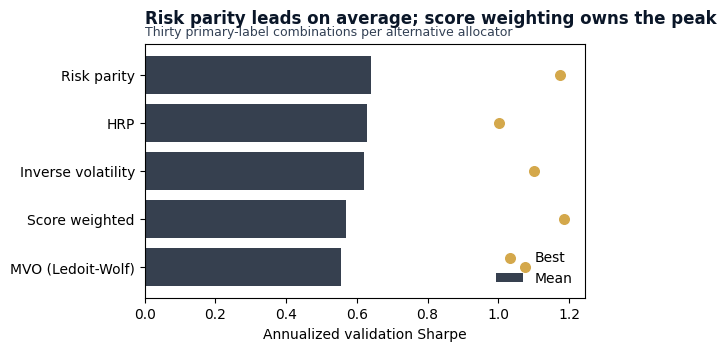

In [10]:
plot_alloc = alloc_comparison.sort("avg_sharpe")
fig, ax = plt.subplots(figsize=FIGSIZE["single"], constrained_layout=True)
y = range(len(plot_alloc))
allocator_labels = {
    "score_weighted": "Score weighted",
    "inverse_vol": "Inverse volatility",
    "risk_parity": "Risk parity",
    "mvo_ledoit_wolf": "MVO (Ledoit-Wolf)",
    "hrp": "HRP",
}
labels = [allocator_labels[name] for name in plot_alloc["allocator"].to_list()]
ax.barh(y, plot_alloc["avg_sharpe"], color=COLORS["blue"], alpha=0.82, label="Mean")
ax.scatter(plot_alloc["best_sharpe"], y, color=COLORS["amber"], s=48, zorder=3, label="Best")
ax.set_yticks(list(y), labels)
ax.set_xlabel("Annualized validation Sharpe")
ax.legend(frameon=False, loc="lower right")
add_message_title(
    ax,
    "Risk parity leads on average; score weighting owns the peak",
    "Thirty primary-label combinations per alternative allocator",
)
fig.show()

## 4. Inspect the allocation winner

The best allocation combines NLinear predictions, ten selected stocks, and
score weighting. The table keeps the top ten visible while the next figure
shows whether that result depends on one concentration choice.

In [11]:
top_rows = explorer.best(
    stage="allocation",
    top_n=10,
    label=LABEL,
    prediction_hashes=selected_hashes,
)
winner = explorer.inspect(top_rows["backtest_hash"][0])
winner_strategy = winner.spec["strategy"]
winner_allocator = winner_strategy["allocation"]["method"]
winner_top_k = winner_strategy["signal"]["top_k"]
baseline_sharpe = top_preds.filter(pl.col("prediction_hash") == winner.prediction_hash)["sharpe"][0]
allocation_delta = winner.metrics["sharpe"] - baseline_sharpe

print(
    f"Winner: {winner.source}; allocator={winner_allocator}; top_k={winner_top_k}; "
    f"Sharpe={winner.metrics['sharpe']:.3f} "
    f"[{winner.metrics['sharpe_ci95_lo']:.3f}, {winner.metrics['sharpe_ci95_hi']:.3f}]"
)
print(f"Equal-weight baseline={baseline_sharpe:.3f}; allocation delta={allocation_delta:+.3f}")
top_rows.select("source", "prediction_hash", "sharpe", "cagr", "max_drawdown")

Winner: deep_learning/nlinear; allocator=score_weighted; top_k=10; Sharpe=1.186 [0.032, 2.426]
Equal-weight baseline=0.826; allocation delta=+0.360


source,prediction_hash,sharpe,cagr,max_drawdown
str,str,f64,f64,f64
"""deep_learning/nlinear""","""07841c23bf72""",1.185942,0.583297,-0.328773
"""deep_learning/nlinear""","""07841c23bf72""",1.185326,0.682342,-0.380283
"""deep_learning/nlinear""","""07841c23bf72""",1.175167,0.508468,-0.307562
"""deep_learning/nlinear""","""07841c23bf72""",1.099783,0.476354,-0.332363
"""deep_learning/nlinear""","""07841c23bf72""",1.076082,0.688266,-0.574199
"""deep_learning/nlinear""","""07841c23bf72""",1.035564,0.519154,-0.367961
"""deep_learning/nlinear""","""07841c23bf72""",1.033273,0.507686,-0.359644
"""deep_learning/nlinear""","""07841c23bf72""",1.002837,0.387643,-0.303172
"""latent_factors/sdf""","""11292ff56cd3""",1.00254,0.522846,-0.570366


Five or ten selected stocks preserve NLinear's allocation edge across the
eligible alternatives. Expanding to twenty names lowers Sharpe for every
allocator, which is consistent with dilution of the cross-sectional ranking.

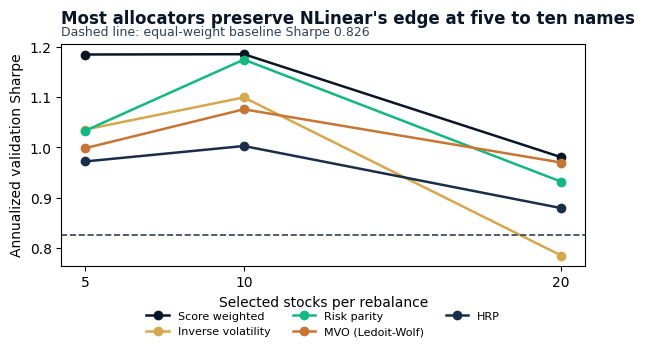

In [12]:
winner_curve = explorer.concentration_curve(winner.prediction_hash).filter(
    pl.col("allocator").is_in(allocation_methods)
)
palette = [
    COLORS["blue"],
    COLORS["amber"],
    COLORS["positive"],
    COLORS["copper"],
    COLORS["slate"],
    COLORS["neutral"],
][: len(allocation_methods)]

fig, ax = plt.subplots(figsize=FIGSIZE["single"], constrained_layout=True)
for color, method in zip(palette, allocation_methods, strict=True):
    curve = winner_curve.filter(pl.col("allocator") == method).sort("top_k")
    ax.plot(
        curve["top_k"],
        curve["sharpe"],
        marker="o",
        linewidth=1.8,
        color=color,
        label=allocator_labels[method],
    )
ax.axhline(baseline_sharpe, color=COLORS["neutral"], linestyle="--", linewidth=1.2)
ax.set_xticks(TOP_K_VALUES)
ax.set_xlabel("Selected stocks per rebalance")
ax.set_ylabel("Annualized validation Sharpe")
ax.legend(
    frameon=False,
    ncol=3,
    fontsize=8,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16),
)
add_message_title(
    ax,
    "Most allocators preserve NLinear's edge at five to ten names",
    f"Dashed line: equal-weight baseline Sharpe {baseline_sharpe:.3f}",
)
fig.show()

## Key takeaways

1. The allocation funnel advances ten distinct full-coverage configurations;
   the 2021 holdout is not consulted.
2. Risk parity leads the method averages at validation Sharpe 0.639. Score
   weighting produces the peak result: NLinear, top 10, Sharpe 1.186 with a
   block-bootstrap interval of [0.032, 2.426].
3. Allocation raises the winning NLinear lineage from an equal-weight baseline
   Sharpe of 0.826 to 1.186, a validation improvement of 0.360.
4. Twenty-name portfolios dilute the NLinear result across all five eligible
   alternatives.
5. These are selection-stage results on a current-constituent universe, so
   they retain survivorship bias and do not establish an out-of-sample edge.

**Next:** `16_costs` applies realistic friction assumptions to the best
validation lineage. See Chapter 18 for the transaction-cost framework.